<a href="https://colab.research.google.com/github/SangeethaKumari/AI-Learning-Projects/blob/main/data_visualization_univariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
# Set the visual style for a clean, professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:

# 1. Load a stable mirror of the Kaggle Student Performance Dataset
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

In [4]:
# Clean up column names for seamless DataFrame access
df.columns = df.columns.str.replace(' ', '_').str.replace('/', '_')

print("Dataset successfully loaded!")
print(df.head(2))

Dataset successfully loaded!
   gender race_ethnicity parental_level_of_education     lunch  \
0  female        group B           bachelor's degree  standard   
1  female        group C                some college  standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0



--- Summary Statistics vs. Distribution Reality ---
Group A Reading -> Mean: 64.7 | Median: 64.0 | Std Dev: 15.5
Group B Reading -> Mean: 67.4 | Median: 67.0 | Std Dev: 15.2


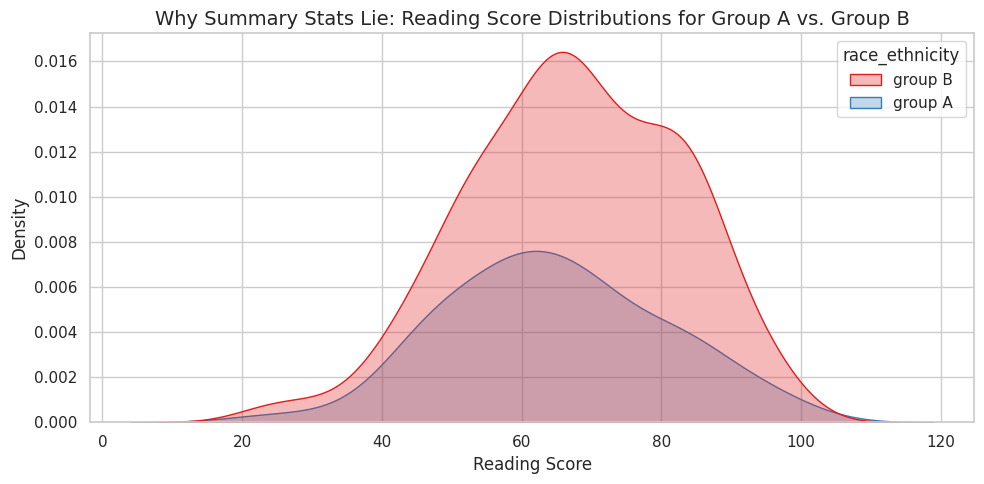

In [10]:
# =====================================================================
# THE REAL WORLD TRICK: Identical Stats, Different Real Distributions
# =====================================================================
print("\n--- Summary Statistics vs. Distribution Reality ---")

# Let's isolate two distinct demographic groups from the student data
group_a = df[df['race_ethnicity'] == 'group A']['reading_score']
group_b = df[df['race_ethnicity'] == 'group B']['reading_score']

# Compare their standard summary metrics
print(f"Group A Reading -> Mean: {group_a.mean():.1f} | Median: {group_a.median():.1f} | Std Dev: {group_a.std():.1f}")
print(f"Group B Reading -> Mean: {group_b.mean():.1f} | Median: {group_b.median():.1f} | Std Dev: {group_b.std():.1f}")

# The numbers tell you they look identical. Let's see the visual reality!
plt.figure(figsize=(10, 5))

# Layering the two distributions using a Univariate KDE Plot
sns.kdeplot(data=df[df['race_ethnicity'].isin(['group A', 'group B'])],
            x='reading_score', hue='race_ethnicity', fill=True, alpha=0.3, palette='Set1')

plt.title("Why Summary Stats Lie: Reading Score Distributions for Group A vs. Group B", fontsize=14)
plt.xlabel("Reading Score")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

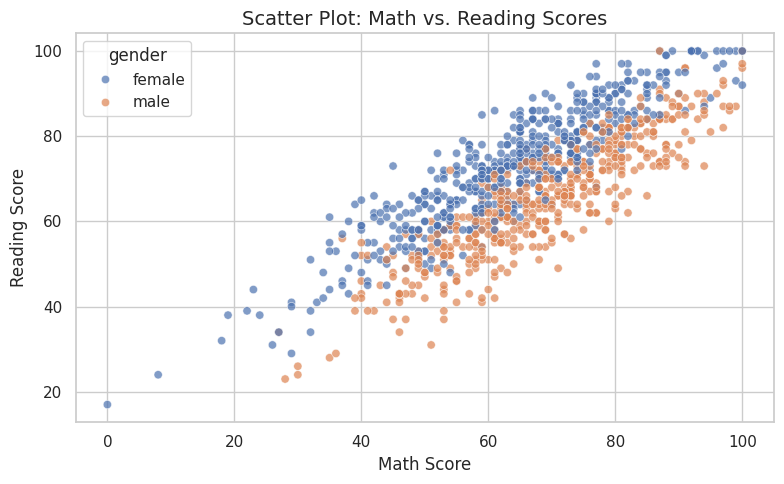

In [5]:
# ==========================================
# SCATTER PLOT: Relationships & Outliers
# ==========================================
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='math_score', y='reading_score', hue='gender', alpha=0.7)
plt.title('Scatter Plot: Math vs. Reading Scores', fontsize=14)
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.tight_layout()
plt.show()

In [ ]:
# Observation: Generally, it suggests a positive correlation: students who score higher in math tend to score higher in reading as well, and vice versa. The plot also uses color to distinguish between genders, which can help in visually identifying if there are any distinct patterns or differences in performance between male and female students across these two subjects.

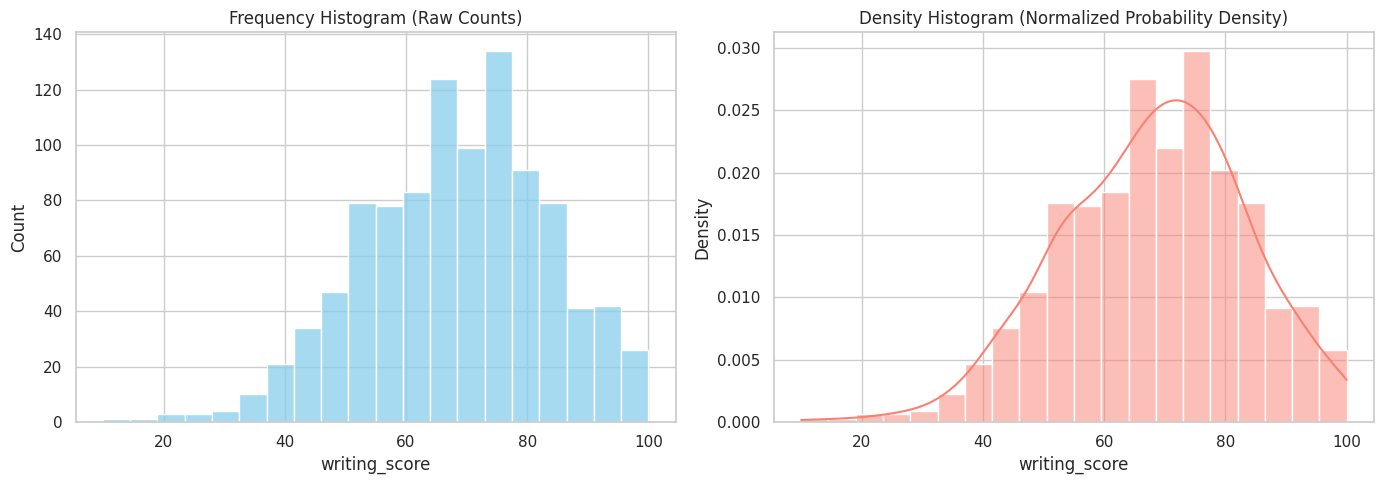

In [7]:
# ==========================================
# HISTOGRAMS: Frequency vs. Density
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Frequency Histogram
sns.histplot(data=df, x='writing_score', bins=20, ax=axes[0], color='skyblue')
axes[0].set_title('Frequency Histogram (Raw Counts)', fontsize=12)

# Right: Density Histogram with KDE
sns.histplot(data=df, x='writing_score', bins=20, stat='density', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Density Histogram (Normalized Probability Density)', fontsize=12)

plt.tight_layout()
plt.show()

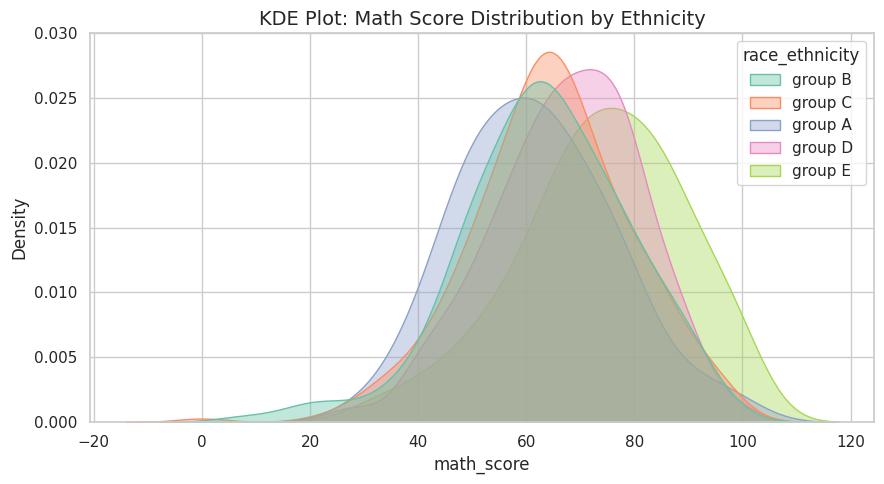

In [8]:
# ==========================================
# KDE DISTRIBUTION BY CATEGORY
# ==========================================
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='math_score', hue='race_ethnicity', fill=True, common_norm=False, palette='Set2', alpha=0.4)
plt.title('KDE Plot: Math Score Distribution by Ethnicity', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2247/3371442781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parental_level_of_education', y='math_score', ax=axes[0], palette='Pastel1')
/tmp/ipykernel_2247/3371442781.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2247/3371442781.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


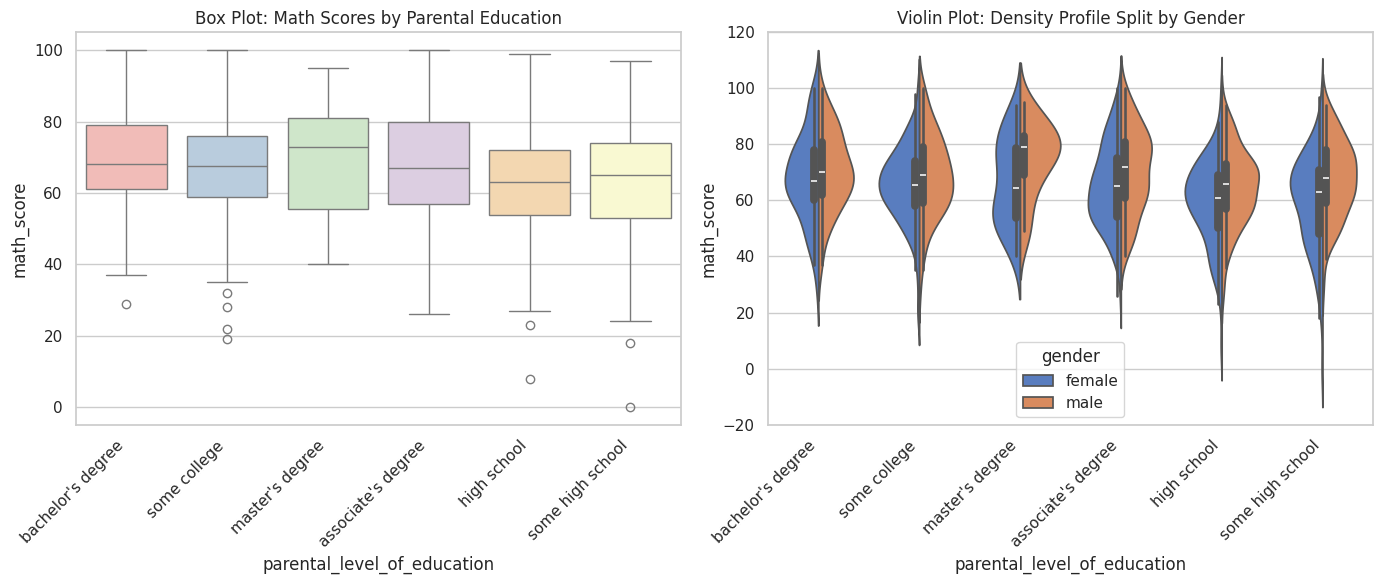

In [9]:
# ==========================================
# BOX PLOT vs. VIOLIN PLOT
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Box Plot
sns.boxplot(data=df, x='parental_level_of_education', y='math_score', ax=axes[0], palette='Pastel1')
axes[0].set_title('Box Plot: Math Scores by Parental Education', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right: Violin Plot with Split Hue
sns.violinplot(data=df, x='parental_level_of_education', y='math_score', hue='gender', split=True, ax=axes[1], palette='muted')
axes[1].set_title('Violin Plot: Density Profile Split by Gender', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#Observation Box Plot : This plot shows the distribution of math scores for students grouped by their parental level of education. You can observe the median score, interquartile range, and potential outliers for each educational group. This helps in understanding how parental education might correlate with a student's math performance and the spread of scores within each group.

In [ ]:
# Observation Violin plot : This plot extends the analysis by showing the distribution density of math scores across different parental education levels, further split by gender. The 'violin' shape illustrates the density of scores, with wider sections indicating more data points at those score levels. The split by gender allows for a direct visual comparison of score distributions between male and female students within each parental education category, revealing potential differences in typical scores, spread, and the presence of multimodal distributions (multiple peaks in performance).